In [61]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statistics
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [62]:
df = pd.read_csv(r"C:\Users\jacks\OneDrive\Documents\ds-studio-ii\project 1\StudentPerformanceFactors.csv")


In [63]:
df["Motivation_Level"].describe(include="all")

# motivation = low, med, high then describe

count       6607
unique         3
top       Medium
freq        3351
Name: Motivation_Level, dtype: object

In [64]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [65]:
df.shape

(6607, 20)

" Do students having more access to accommodations or special education services affect student happiness levels? (or engagement)"

Issues: I need to rephrase the question because I do not have access to happiness levels but I can see their motivation levels

Access to Resources: Availability of educational resources (Low, Medium, High).

Extracurricular Activites: Participation in extracurricular activities (Yes, No)

Motivation Level: Student's level of motivation (Low, Medium, High).

Previous Scores: Scores from previous exams.

Possible Graphs:
Need a graph that shows the relation between ML and AR, hopefully a positive one but these might have to be turned in numbers
- same for ML and EX
- same for ML and PS

* Line graphs
ML on x (1, 2 ,3) and AR on y (1 and 2)

* 


Target Variable(s): 
* Motivation Level (string)

Helping Variables: 
* Learning disabilites (string)  
* access to resources (string)
* internet access (string)

other variables I might use if they have influence: 
* Physical activity(int)

Cleaning that might be needed:
* Change motivation level to int (1- Low, 2- Medium, 3- High)
* Everything else is Yes(1) and No(0)

^ This is drafting and brainstorming nothing is final

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [67]:
## check for missing values
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [68]:
#check for outliers

# Calculate IQR
q1= np.percentile(df['Exam_Score'], 25 )
q3= np.percentile(df['Exam_Score'], 75)

iqr = q3-q1

# Calculate Threshold

threshold = 1.5*iqr
lowb = q1-threshold
upb = q3+threshold


# Identify Outliers
outliers = df[(df['Exam_Score'] <= lowb ) | (df['Exam_Score'] >= upb)]

print("There are ", len(outliers), "Outliers for Exam Scores")

There are  192 Outliers for Exam Scores


In [69]:
## check for missing values

df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

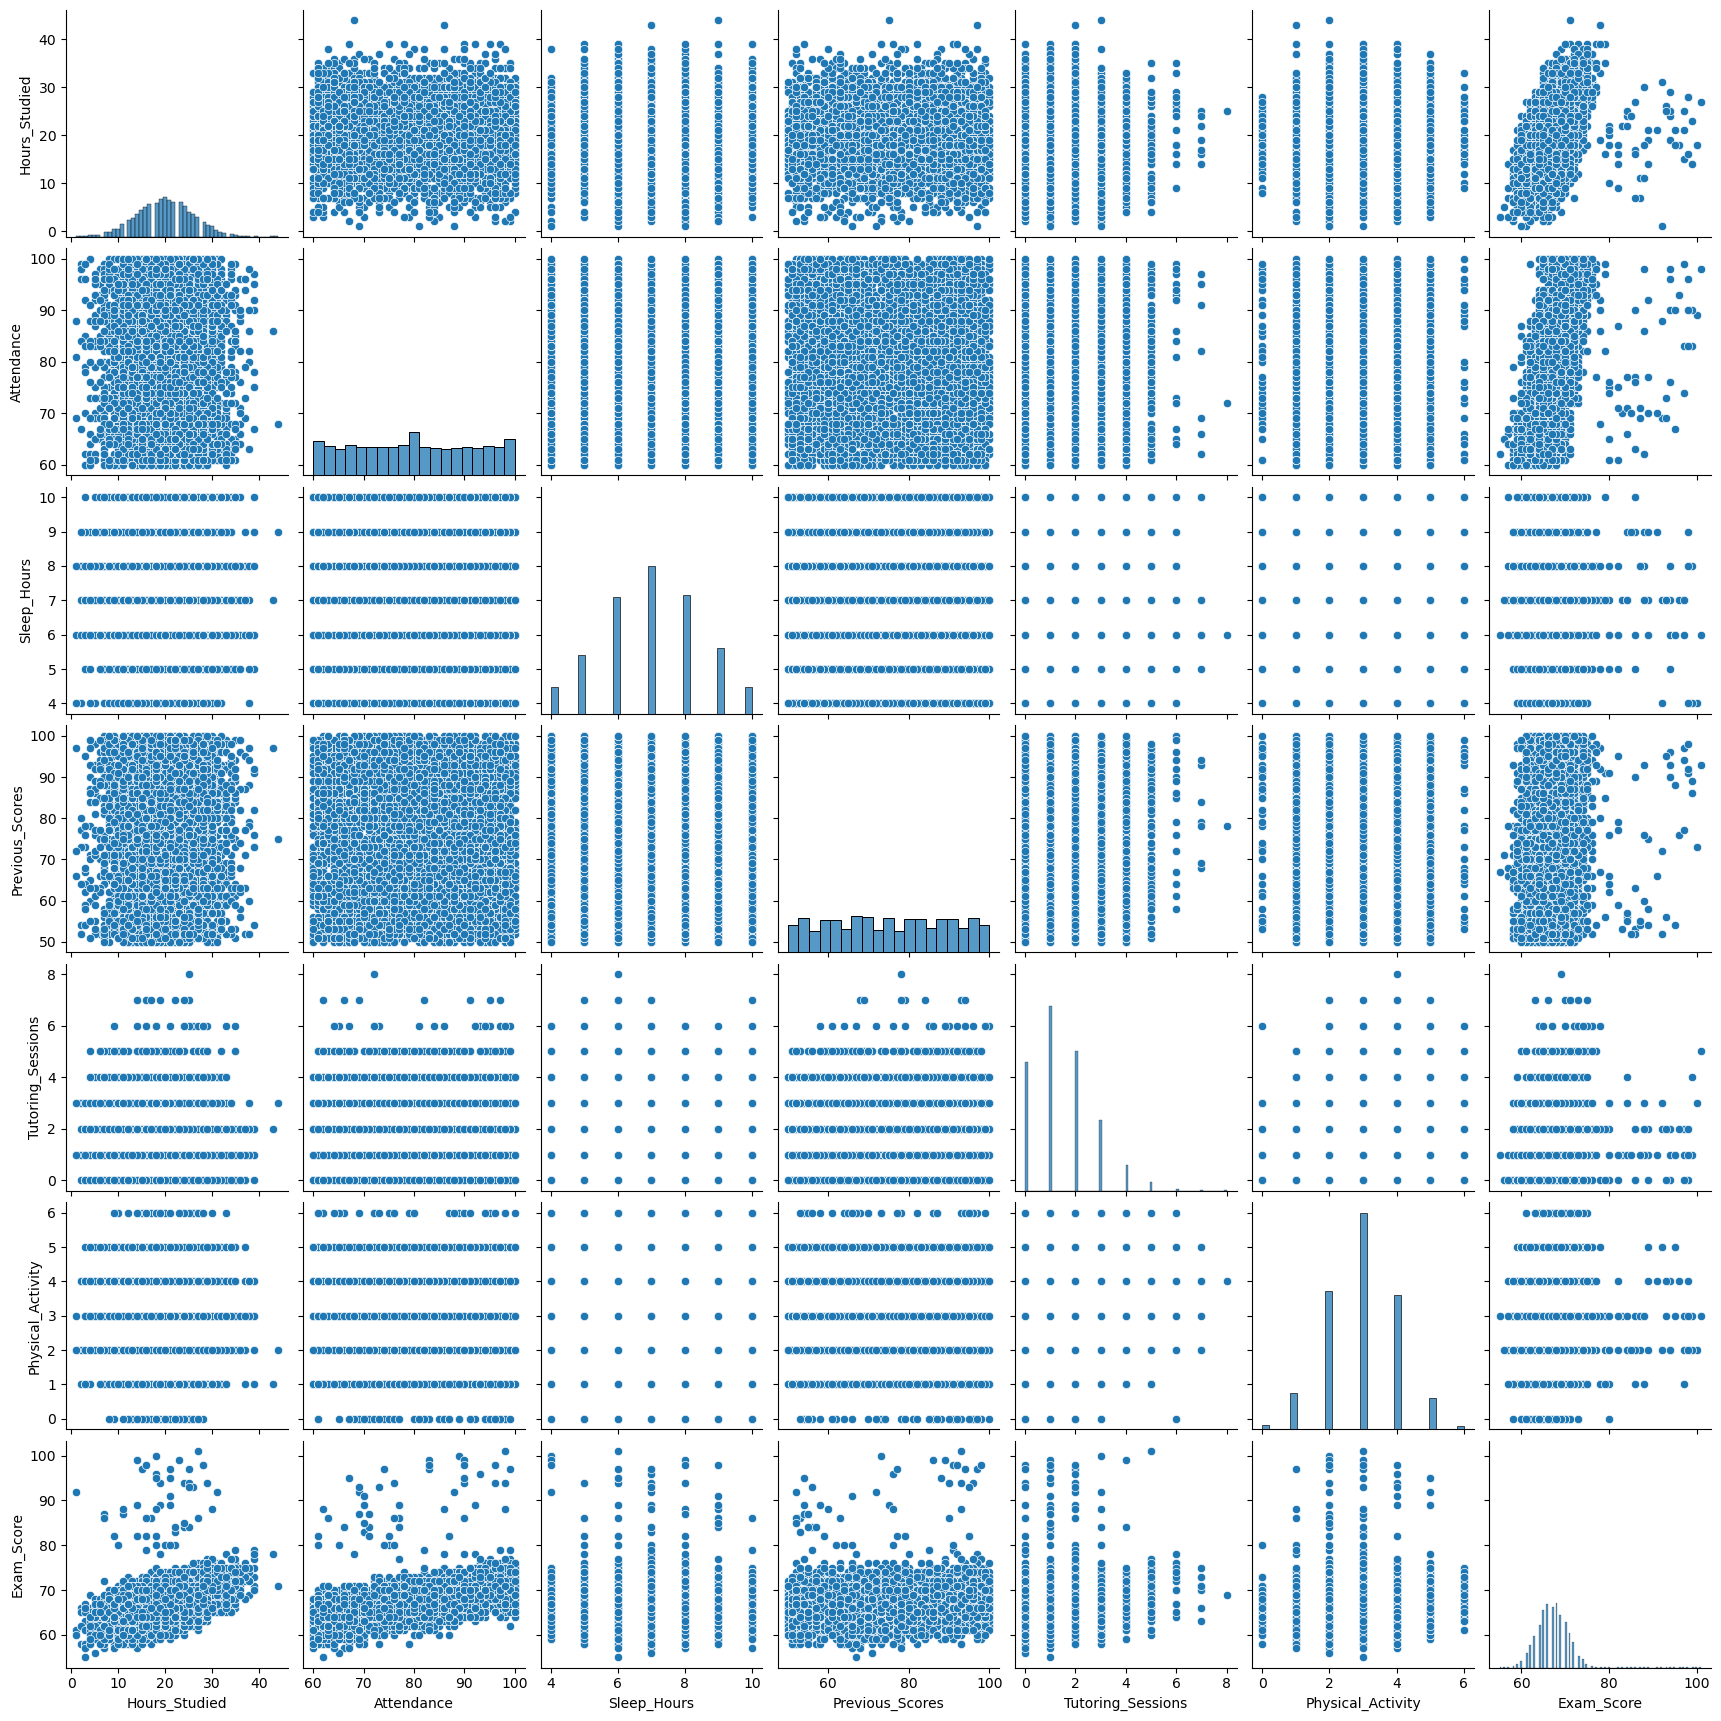

In [70]:
sns.pairplot(data=df)

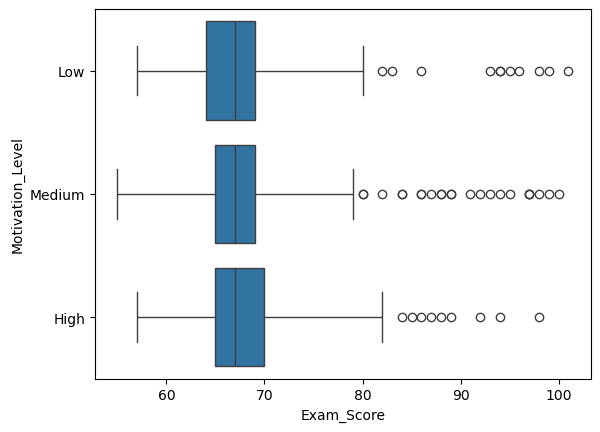

In [71]:
## look for outliers
sns.boxplot(data=df, x='Exam_Score',y='Motivation_Level', whis=2.5)
plt.show()

<Axes: xlabel='Motivation_Level', ylabel='Count'>

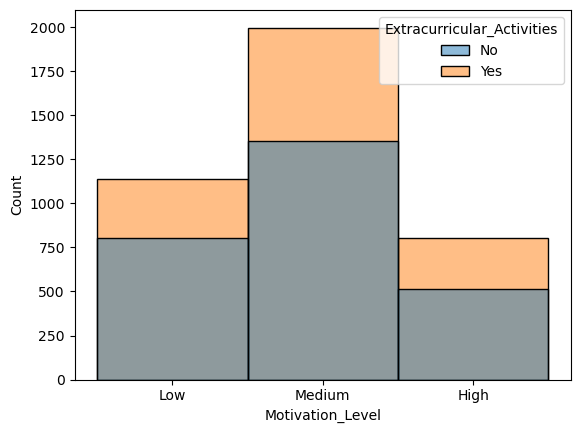

In [72]:
sns.histplot(data=df, x='Motivation_Level', hue='Extracurricular_Activities')

In [73]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 48 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Hours_Studied                          6607 non-null   int64
 1   Attendance                             6607 non-null   int64
 2   Sleep_Hours                            6607 non-null   int64
 3   Previous_Scores                        6607 non-null   int64
 4   Tutoring_Sessions                      6607 non-null   int64
 5   Physical_Activity                      6607 non-null   int64
 6   Exam_Score                             6607 non-null   int64
 7   Hours_Studied                          6607 non-null   int64
 8   Attendance                             6607 non-null   int64
 9   Sleep_Hours                            6607 non-null   int64
 10  Previous_Scores                        6607 non-null   int64
 11  Tutoring_Sessions             

In [74]:
## TO DO: ONE-HOT ENCODE A CATEGORICAL COLUMN OF YOUR CHOICE## 


cat_cols = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Motivation_Level",
    "Internet_Access",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender"
]




dummies = pd.get_dummies(data=df, columns=cat_cols)



In [75]:
### Got second part of this code from https://www.geeksforgeeks.org/python/how-to-convert-categorical-variable-to-numeric-in-pandas/ 

df_new = pd.concat([df, dummies], axis=1).drop(cat_cols, axis=1)

<Axes: xlabel='Motivation_Level', ylabel='Count'>

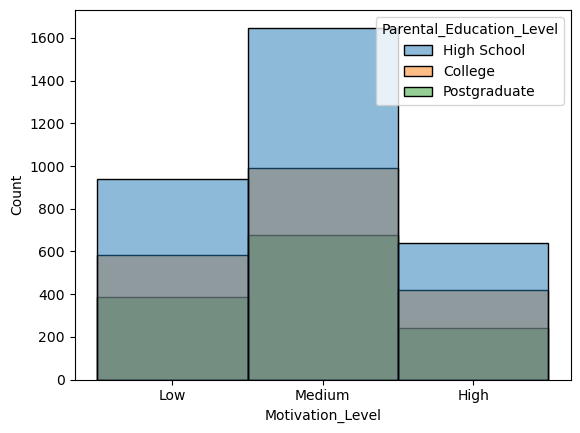

In [76]:
sns.histplot(data=df, x='Motivation_Level', hue='Parental_Education_Level')

<Axes: >

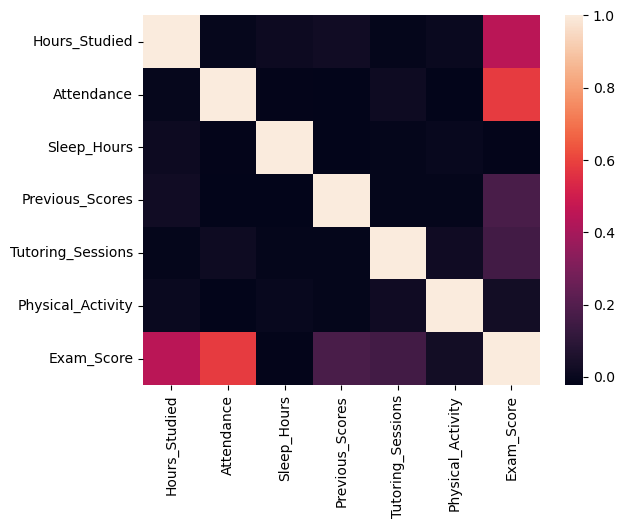

In [77]:
sns.heatmap(df.corr(numeric_only=True))

## df.groupby([column2],[column1])["gold"].sub()

## instead of .sub() I can use .unique() or .count()

## .agg({"gold":"sum"})

In [ ]:
## Check distribution

df.groupby('Motivation_Level')[df.columns].count()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
Motivation_Level,,,,,,,,,,,,,,,,,,,,
High,1319,1319,1319,1319,1319,1319,1319,1319,1319,1319,1319,1306,1319,1319,1319,1319,1300,1309,1319,1319
Low,1937,1937,1937,1937,1937,1937,1937,1937,1937,1937,1937,1911,1937,1937,1937,1937,1904,1921,1937,1937
Medium,3351,3351,3351,3351,3351,3351,3351,3351,3351,3351,3351,3312,3351,3351,3351,3351,3313,3310,3351,3351
